In [11]:
import argparse
import torch
from torch import nn, Tensor
from typing import Optional, Union, Tuple, List, Any
import torch.optim as optim
from torch.ao.quantization import QuantStub, DeQuantStub
from torch.nn.quantized import FloatFunctional


import os
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO


from cv_nets.utils.config_helper import get_param
from cv_nets.layers.activation import build_activation_layer
from cv_nets.layers.normalization import build_normalization_layer
from cv_nets.layers.pooling import build_pooling_layer
from cv_nets.layers import *

In [12]:
class DoubleConvBlock(nn.Module):
    def __init__(self, opts: Any, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv1 = Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm1 = build_normalization_layer(opts, num_features=out_channels)
        self.act1 = build_activation_layer(opts)
        self.conv2 = Conv2d(
            in_channels=out_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm2 = build_normalization_layer(opts, num_features=out_channels)
        self.act2 = build_activation_layer(opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.act1(self.norm1(self.conv1(x)))
        x = self.act2(self.norm2(self.conv2(x)))
        return x


class UNetLite(nn.Module):
    def __init__(self, opts: Any = None, num_classes: int = 1) -> None:
        super().__init__()
        features = [16, 32, 64, 128]
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.f_cat = FloatFunctional()

        self.encoder_blocks = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        in_ch = 3 
        for feat in features:
            self.encoder_blocks.append(DoubleConvBlock(opts, in_ch, feat))
            self.downsample_layers.append(
                Conv2d(in_channels=feat, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            in_ch = feat
            
        self.bottleneck = DoubleConvBlock(opts, features[-1], features[-1] * 2) 

        self.decoder_blocks = nn.ModuleList()
        self.upsample_layers = nn.ModuleList()
        
        for feat in reversed(features):
            self.upsample_layers.append(
                ConvTranspose2d(in_channels=feat * 2, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            self.decoder_blocks.append(DoubleConvBlock(opts, feat * 2, feat))

        self.final_conv = Conv2d(in_channels=features[0], out_channels=num_classes, kernel_size=1, stride=1, padding=0, opts=opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.quant(x)

        skip_connections: List[Tensor] = []
        
        for i in range(len(self.encoder_blocks)):
            x = self.encoder_blocks[i](x)
            skip_connections.append(x)  
            x = self.downsample_layers[i](x)
            
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        
        for i in range(len(self.decoder_blocks)):
            x = self.upsample_layers[i](x)     
            skip_connection = skip_connections[i] 
            x_cat = self.f_cat.cat((skip_connection, x), dim=1)
            x = self.decoder_blocks[i](x_cat)   
            
        x = self.final_conv(x)
        x = self.dequant(x)
        return x


In [13]:
model = UNetLite(num_classes= 1)
print(model)

UNetLite(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (f_cat): FloatFunctional(
    (activation_post_process): Identity()
  )
  (encoder_blocks): ModuleList(
    (0): DoubleConvBlock(
      (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU : inplace False
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU : inplace False
    )
    (1): DoubleConvBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU : inplace False
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): 

In [14]:
class COCOPersonDataset(Dataset):
    """
    Dataset tùy chỉnh để lấy ảnh và tạo mask nhị phân cho class 'Person'
    """
    def __init__(self, img_dir, ann_file, image_size=(320, 320)):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.image_size = image_size
        
        self.person_cat_id = self.coco.getCatIds(catNms=['person'])[0]
        self.img_ids = self.coco.getImgIds(catIds=[self.person_cat_id])
        self.img_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[self.person_cat_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask * 255).convert('L')
        mask = mask.resize(self.image_size, Image.NEAREST)
        image_tensor = self.img_transform(image)
        mask_tensor = transforms.ToTensor()(mask) 
        
        return image_tensor, mask_tensor

In [15]:
def calculate_iou(preds, masks, threshold=0.5):
    """Tính Intersection over Union (IoU) cho Segmentation"""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold
    
    intersection = (preds & masks).float().sum((1, 2, 3))
    union = (preds | masks).float().sum((1, 2, 3))
    
    # Cộng thêm epsilon nhỏ (1e-6) để tránh lỗi chia cho 0
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [16]:
train_img_dir = './COCO/train2017'
train_ann_file = './COCO/annotations/instances_train2017.json'

val_img_dir = './COCO/val2017'
val_ann_file = './COCO/annotations/instances_val2017.json'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [17]:
print("Đang tải COCO Train Annotations...")
train_dataset = COCOPersonDataset(train_img_dir, train_ann_file, image_size=(320, 320))

Đang tải COCO Train Annotations...
loading annotations into memory...
Done (t=9.06s)
creating index...
index created!


In [18]:

print("Đang tải COCO Val Annotations...")
val_dataset = COCOPersonDataset(val_img_dir, val_ann_file, image_size=(320, 320))

Đang tải COCO Val Annotations...
loading annotations into memory...
Done (t=2.48s)
creating index...
index created!


In [19]:
print(f"Tìm thấy {len(train_dataset)} ảnh Train và {len(val_dataset)} ảnh Val chứa người.")

Tìm thấy 64115 ảnh Train và 2693 ảnh Val chứa người.


In [21]:
batch_size = 16

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=16,  
    pin_memory=True 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=16,  
    pin_memory=True 
)

model = UNetLite(num_classes=1).to(device)

scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)


    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", unit="batch", leave=False)
    
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)

    print(f"-> Epoch {epoch+1} Kết thúc | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint_path = f"unet_best_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
        }, checkpoint_path)
        print(f"Đã lưu mô hình tốt nhất tại: {checkpoint_path}\n")
    else:
        print("\n")

/tmp/ipykernel_41374/549894898.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
Epoch 1/10 [Train]: 100%|██████████| 4008/4008 [08:25<00:00,  7.93batch/s, loss=0.1494]


-> Epoch 1 Kết thúc | Train Loss: 0.2957 | Val Loss: 0.2499 | Val IoU: 0.3666
Đã lưu mô hình tốt nhất tại: unet_best_epoch_1.pth



Epoch 2/10 [Train]: 100%|██████████| 4008/4008 [08:18<00:00,  8.04batch/s, loss=0.2627]


-> Epoch 2 Kết thúc | Train Loss: 0.2200 | Val Loss: 0.2044 | Val IoU: 0.4784
Đã lưu mô hình tốt nhất tại: unet_best_epoch_2.pth



Epoch 3/10 [Train]: 100%|██████████| 4008/4008 [08:21<00:00,  7.98batch/s, loss=0.2339]


...

-> Epoch 8 Kết thúc | Train Loss: 0.1443 | Val Loss: 0.1562 | Val IoU: 0.5525
Đã lưu mô hình tốt nhất tại: unet_best_epoch_8.pth



Epoch 9/10 [Train]: 100%|██████████| 4008/4008 [08:11<00:00,  8.15batch/s, loss=0.1681]


-> Epoch 9 Kết thúc | Train Loss: 0.1393 | Val Loss: 0.1583 | Val IoU: 0.5040




Epoch 10/10 [Train]: 100%|██████████| 4008/4008 [08:14<00:00,  8.11batch/s, loss=0.1352]


-> Epoch 10 Kết thúc | Train Loss: 0.1353 | Val Loss: 0.1510 | Val IoU: 0.5577
Đã lưu mô hình tốt nhất tại: unet_best_epoch_10.pth



In [22]:
import matplotlib.pyplot as plt

In [23]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    model.eval()
    samples_shown = 0
    
    # Tạo lưới subplot: 4 hàng, 6 cột (vì mỗi mẫu có 3 ảnh: Input, True Mask, Pred Mask)
    # 2 mẫu mỗi hàng -> 2 x 3 = 6 cột
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    # Hàm giải chuẩn hóa (Un-normalize) để hiển thị ảnh RGB bình thường
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            # Chạy qua model
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            
            # Đưa qua hàm Sigmoid và threshold 0.5 để ra mask nhị phân
            preds = torch.sigmoid(outputs) > 0.5

            # Chuyển dữ liệu về CPU để matplotlib có thể vẽ được
            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                # Xác định vị trí vẽ trên lưới
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3

                # 1. Ảnh gốc (đã được giải chuẩn hóa)
                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1) # Giới hạn giá trị pixel trong khoảng [0, 1]

                # 2. Mask thực tế (Ground Truth)
                gt_mask = masks[i].squeeze().numpy()

                # 3. Mask dự đoán (Prediction)
                pred_mask = preds[i].squeeze().numpy()

                # --- Vẽ Ảnh Gốc ---
                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')

                # --- Vẽ Ground Truth ---
                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                # --- Vẽ Prediction ---
                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_mask, cmap='gray')
                ax_pred.set_title("Prediction")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Input | Ground Truth | Prediction)", fontsize=16, y=0.92)
    plt.show()


Đang trực quan hóa kết quả...


/tmp/ipykernel_41374/3737103698.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load("unet_best_epoch_10.pth") # Sửa lại tên file theo epoch tốt 

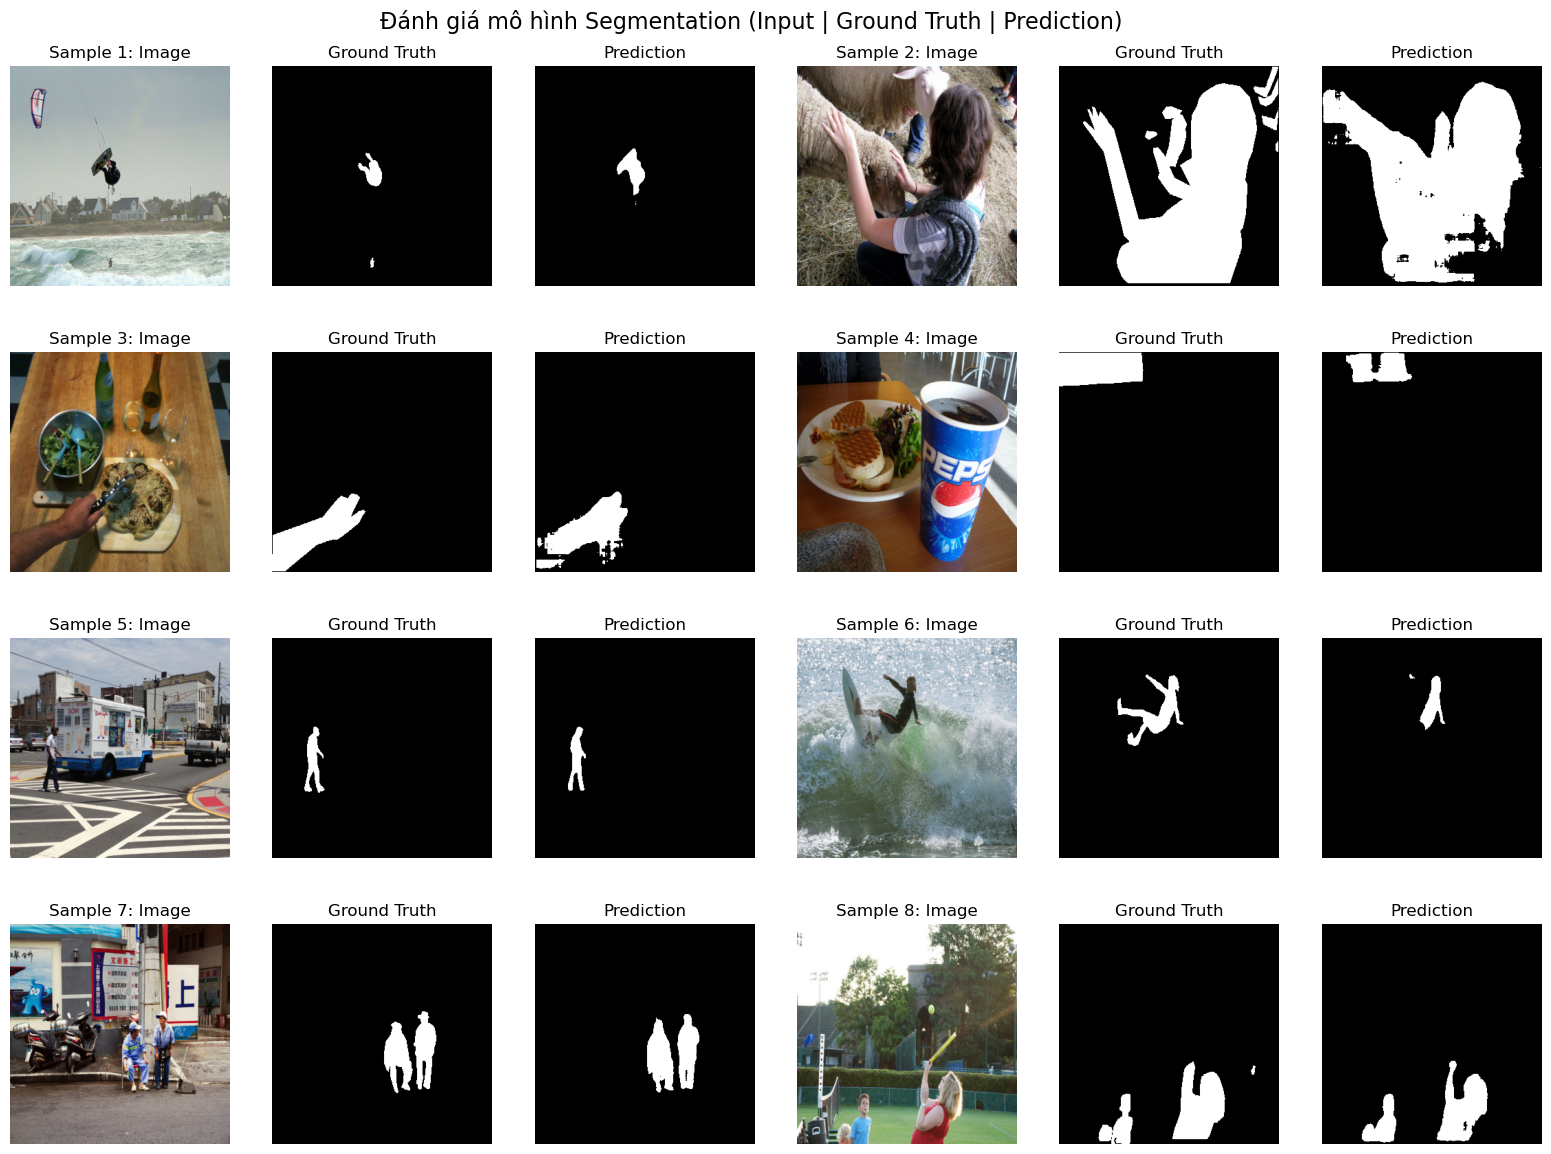

In [24]:
# Load lại model tốt nhất (nếu bạn muốn test sau khi train xong)
best_checkpoint = torch.load("unet_best_epoch_10.pth") # Sửa lại tên file theo epoch tốt nhất của bạn
model.load_state_dict(best_checkpoint['model_state_dict'])

# Hiển thị 8 ảnh ngẫu nhiên từ tập Validation
print("\nĐang trực quan hóa kết quả...")
visualize_predictions(model, val_loader, device, num_samples=8)

In [ ]:
def apply_color_mask(image, mask, color=(0.0, 1.0, 0.0), alpha=0.5):
    """
    Phủ một lớp màu bán trong suốt lên vùng có mask.
    - image: mảng numpy ảnh gốc (H, W, 3), giá trị [0, 1]
    - mask: mảng numpy nhị phân (H, W), giá trị 0 hoặc 1
    - color: tuple màu RGB (mặc định Xanh lá)
    - alpha: độ trong suốt (0.0 -> 1.0)
    """
    colored_image = image.copy()
    # Lặp qua 3 kênh màu (R, G, B)
    for c in range(3):
        colored_image[:, :, c] = np.where(
            mask > 0,
            image[:, :, c] * (1 - alpha) + alpha * color[c],
            image[:, :, c]
        )
    return np.clip(colored_image, 0, 1)

def visualize_predictions_colored(model, dataloader, device, num_samples=8):
    model.eval()
    samples_shown = 0
    
    # Tạo lưới subplot 4 hàng x 6 cột (mỗi mẫu tốn 3 cột)
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    # Giải chuẩn hóa
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            
            # Ngưỡng 0.5 để tạo mask nhị phân
            preds = torch.sigmoid(outputs) > 0.5

            # Đưa về CPU để vẽ
            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3

                # 1. Ảnh gốc
                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                # 2. Xử lý mask
                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                # Phủ màu lên ảnh: Xanh lá cho Thực tế, Đỏ cho Dự đoán
                gt_overlay = apply_color_mask(img, gt_mask, color=(0.0, 1.0, 0.0), alpha=0.5)
                pred_overlay = apply_color_mask(img, pred_mask, color=(1.0, 0.0, 0.0), alpha=0.5)

                # --- Vẽ Ảnh Gốc ---
                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}")
                ax_img.axis('off')

                # --- Vẽ Ground Truth (Màu Xanh) ---
                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_overlay)
                ax_gt.set_title("Truth (Green)")
                ax_gt.axis('off')

                # --- Vẽ Prediction (Màu Đỏ) ---
                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_overlay)
                ax_pred.set_title("Pred (Red)")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Overlay Màu)", fontsize=18, y=0.92, fontweight='bold')
    plt.show()

In [ ]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, val_loader, device, num_samples=8)